In [64]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [65]:
from src.evaluation import build_predictions_report

In [66]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [67]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl  registry.json	versions


In [68]:
ARTIFACT = "level_01_daily_total_sales_artifact"

In [69]:
import joblib

from src.data.split import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-09-03 22:56:55.355 | INFO     | src.data.split:load_data:359 - level_01_daily_total | target=sales | 1,941 filas | 191 features (9 categóricas)
2026-09-03 22:56:55.379 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 1,885 rows)
2026-09-03 22:56:55.383 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 28 rows)
2026-09-03 22:56:55.387 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)
2026-09-03 22:56:56.310 | INFO     | src.data.split:split_data:421 - Features: 191 (9 categóricas)


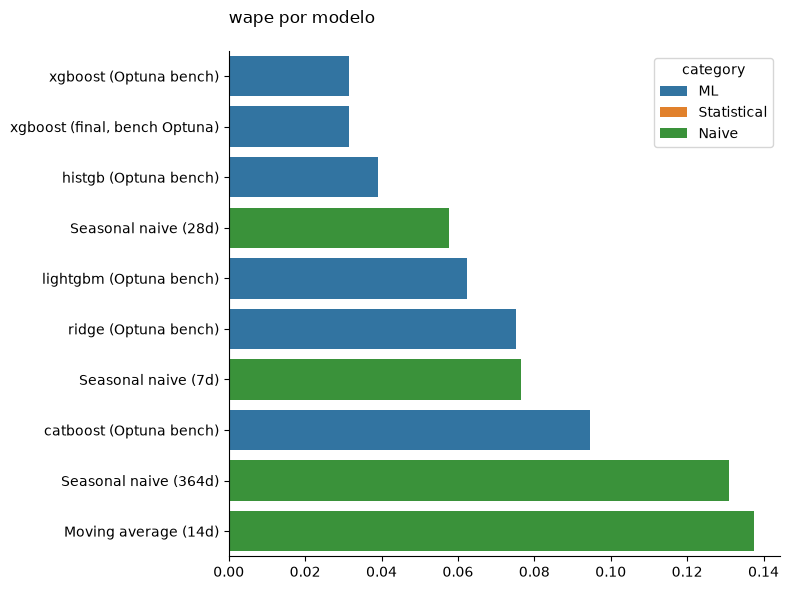

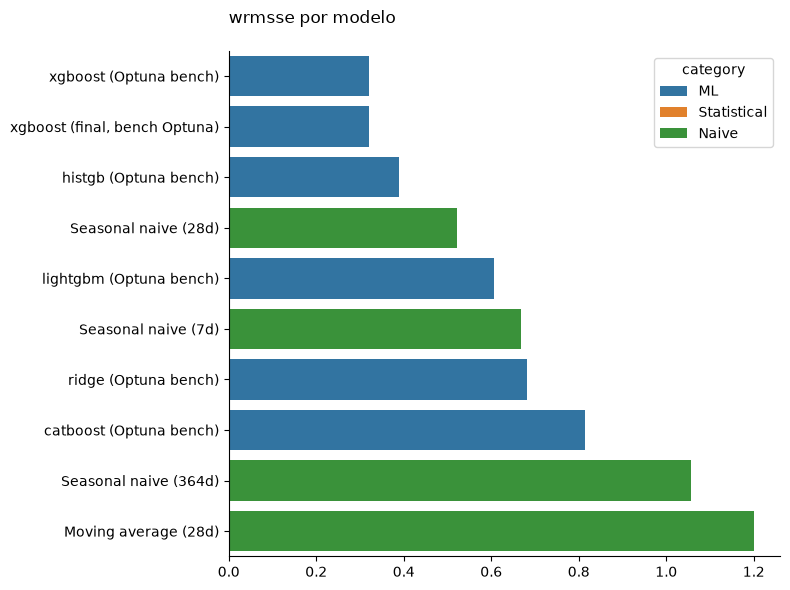

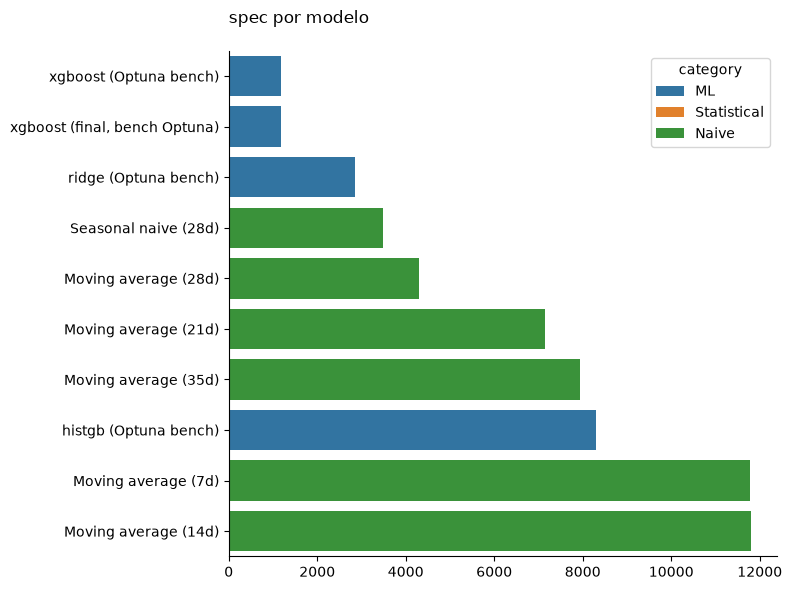

In [70]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df.nsmallest(10, col), hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [71]:
import shap

explainer = artifact["explainer"]

X_shap = model.prepare(X_test.sample(n=min(300_000, len(X_test)), random_state=42))

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
87                             lag28    2575.683105
93                            lag364    1342.846069
51                   te_weekend_mean     875.341492
66                              lag7     546.316406
18                               day     511.974518
..                               ...            ...
102  rolling_mean_lag1_window_size21       0.000000
115  rolling_mean_lag2_window_size14       0.000000
106  rolling_mean_lag1_window_size35       0.000000
133   rolling_min_lag4_window_size14       0.000000
130    rolling_max_lag4_window_size7       0.000000

[191 rows x 2 columns]


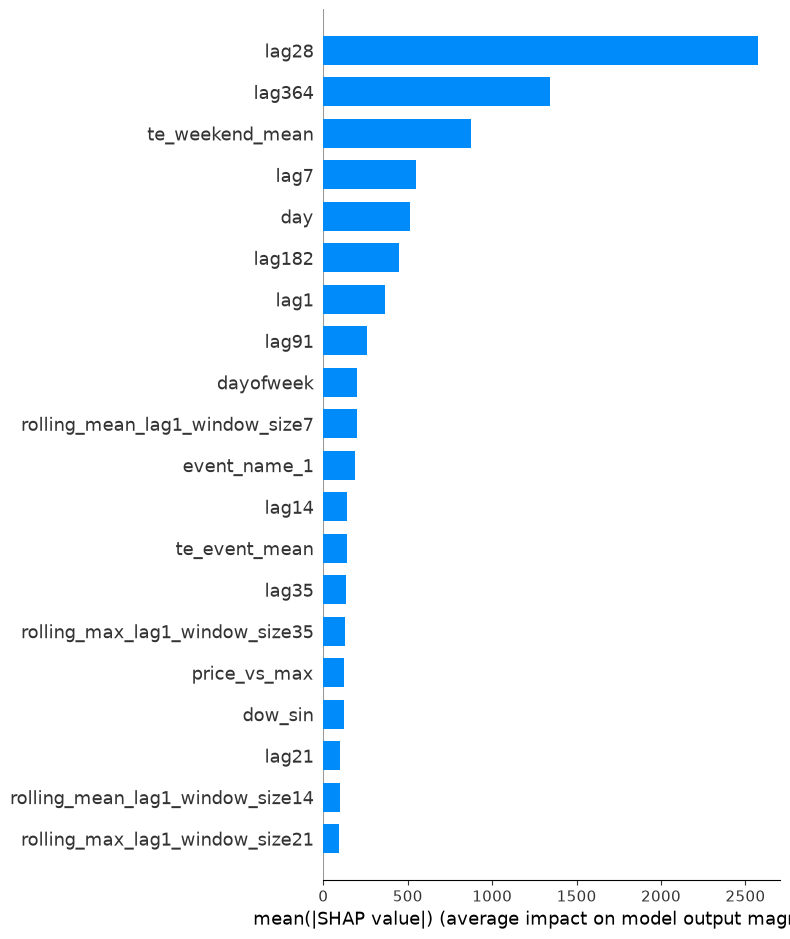

In [72]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [73]:
#shap.summary_plot(shap_values, X_shap)

# Predicciones

In [74]:
from src.evaluation import analizar_prediccion, plot_forecast

In [75]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Total sales: {df_pred['sales'].sum():,.0f}")
print(f"Total predicted: {df_pred['y_pred'].sum():,.0f}")
print(f"Diff: {df_pred['y_pred'].sum() - df_pred['sales'].sum():,.0f}")

print(f"Test WAPE: {metrics_test_final['wape']:.1%}")
print(f"Test BIAS: {metrics_test_final['bias']:.1%}")

print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.3f}")

Total sales: 1,231,764
Total predicted: 1,159,617
Diff: -72,147
Test WAPE: 6.1%
Test BIAS: -5.9%
Test WRMSSE: 0.596


In [76]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
TOTAL,28,28,1231764.0,1159617.0,72147.0,74521.0,3900976.0,1.0,0.060499,-0.058572,0.075226,27.10801,0.647779,0.625826,24575.223214


In [77]:
df_metrics.sort_values('wape').round(4)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
TOTAL,28,28,1231764.0,1159617.0,72147.0,74521.0,3900976.0,1.0,0.0605,-0.0586,0.0752,27.108,0.6478,0.6258,24575.2232


/tmp/ipykernel_69272/1484629979.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_sample = df_pred.query(f'series_id == "{SERIES}"').round(2).copy()


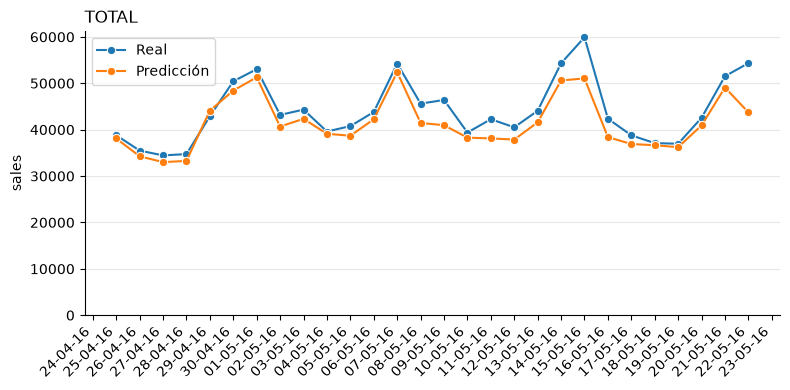

In [78]:
SERIES = 'TOTAL'
df_sample = df_pred.query(f'series_id == "{SERIES}"').round(2).copy()

#display(df_sample)

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=SERIES)
#plot_forecast(df_pred, 'wape', series_id=SERIES)
#plot_forecast(df_pred, 'bias', series_id=SERIES)

################################################## Date: 2016-05-22 00:00:00 ##################################################


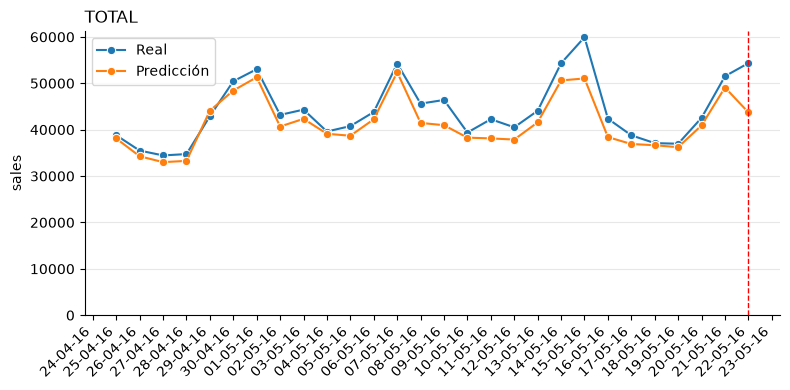

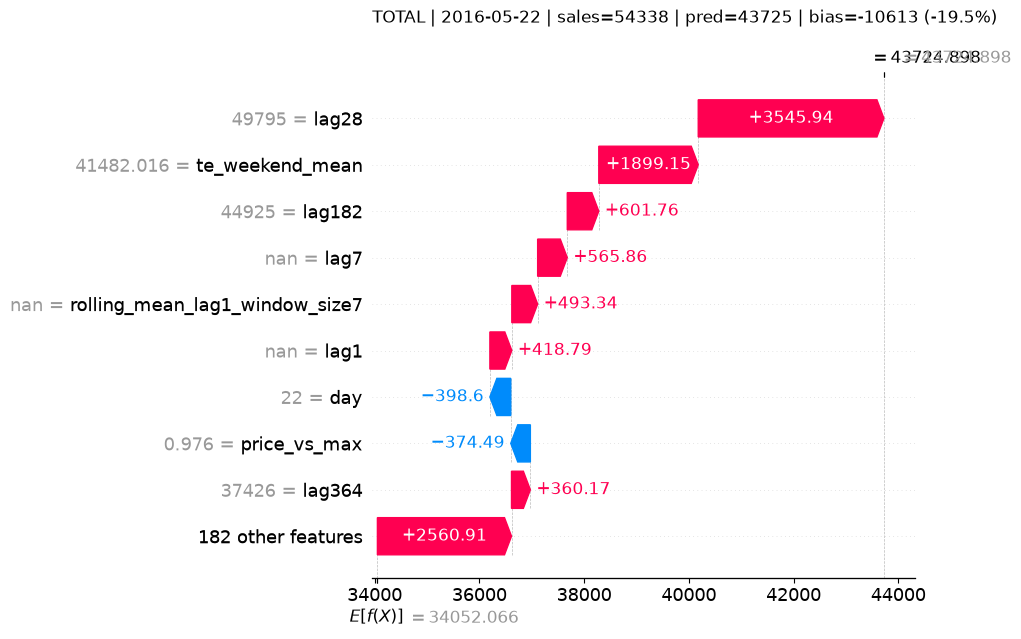

################################################## Date: 2016-05-15 00:00:00 ##################################################


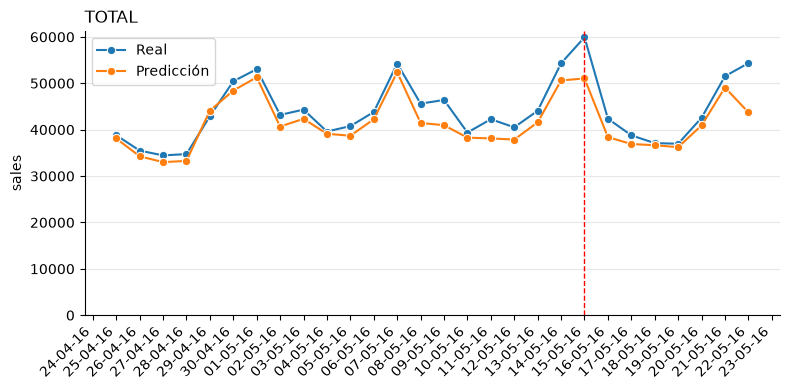

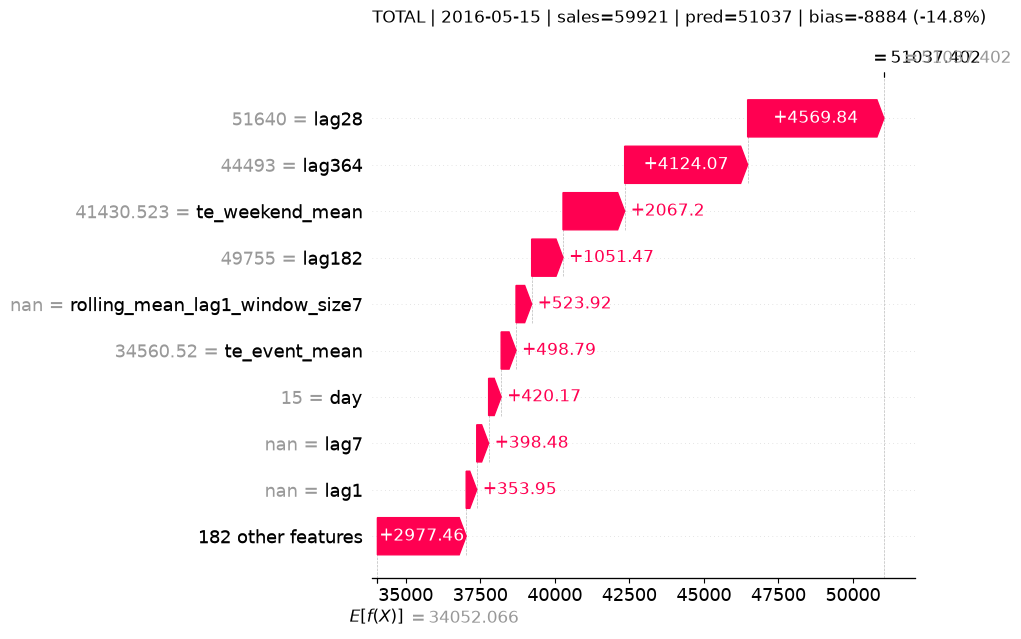

In [79]:
for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

################################################## Date: 2016-05-04 00:00:00 ##################################################


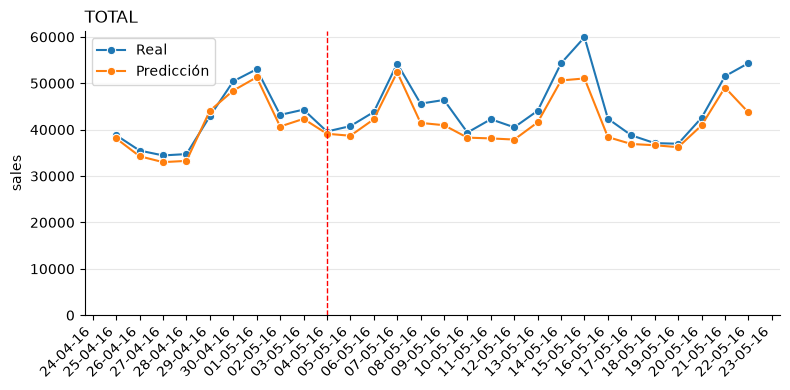

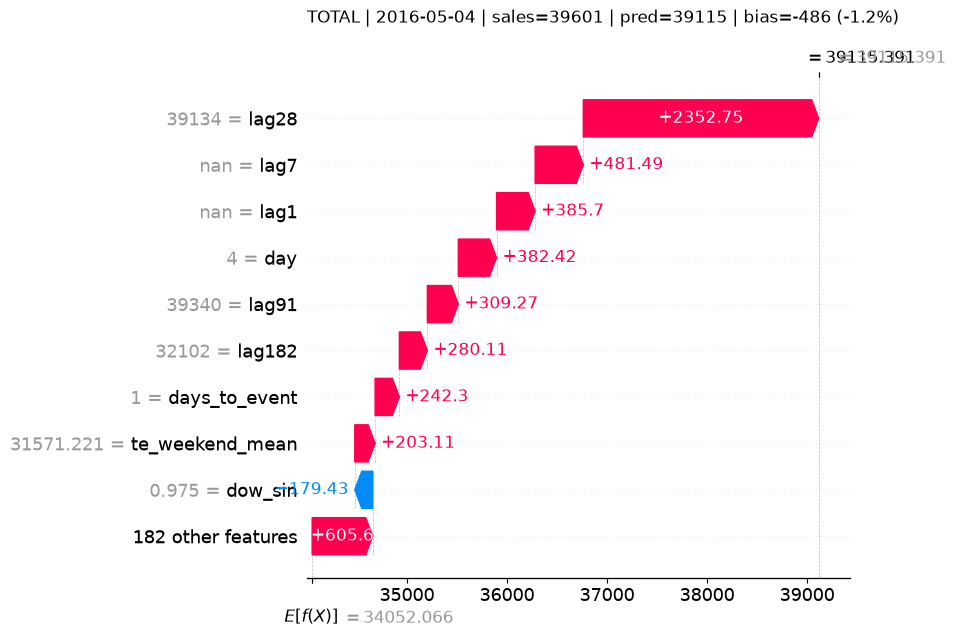

################################################## Date: 2016-05-18 00:00:00 ##################################################


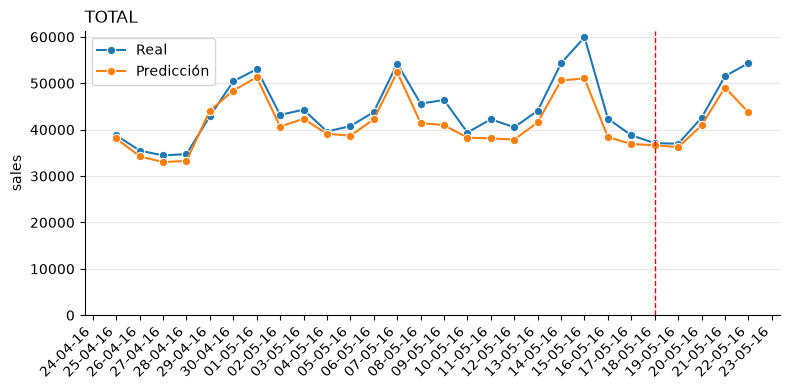

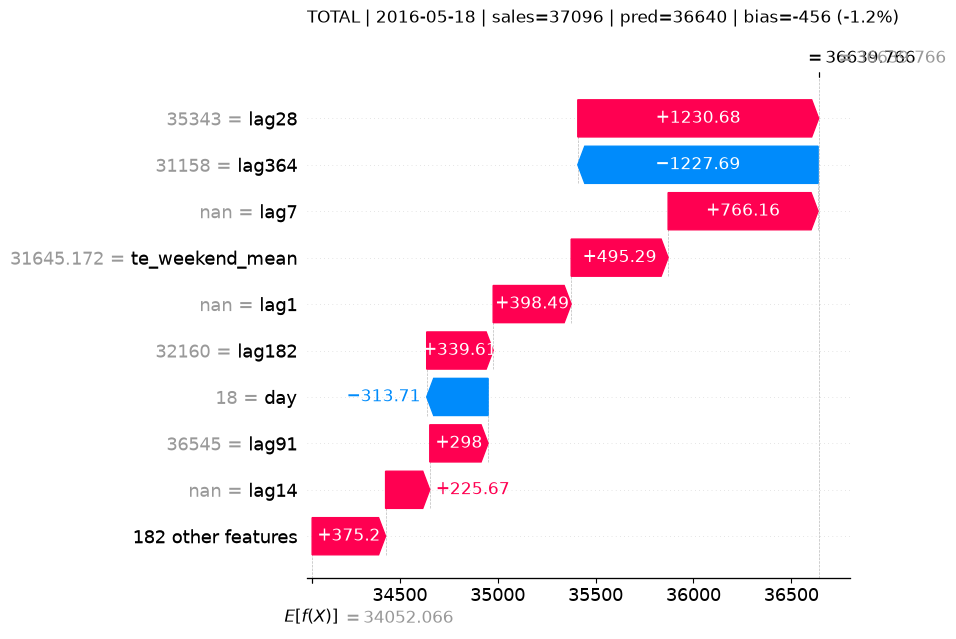

In [80]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)